## MNIST Digit Classification with PyTorch

### Introduction
  
This notebook demonstrates the implementation of a neural network for classifying handwritten digits from the MNIST dataset using PyTorch. We'll go through the process of loading the data, defining the model architecture, training the model, and evaluating its performance.

In [3]:
!pip install -Uqq fastbook
import fastbook
fastbook.setup_book()

In [4]:
# Import necessary libraries
import torch
from torch import nn, optim
from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt


### Data Loading and Preprocessing

We start by importing the necessary libraries and loading the MNIST dataset:

In [6]:
# Load MNIST dataset
train_data = MNIST(root='data', train=True, download=True, transform=ToTensor())
test_data = MNIST(root='data', train=False, download=True, transform=ToTensor())

# Create data loaders
train_dl = DataLoader(train_data, batch_size=64, shuffle=True)
test_dl = DataLoader(test_data, batch_size=64)


The MNIST dataset is automatically downloaded and transformed into PyTorch tensors. We use DataLoader to batch and shuffle the data for efficient training.

### Model Architecture
We define a simple neural network with two hidden layers:

In [9]:
# Define the neural network model
class MnistModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(784, 128)
        self.hidden2 = nn.Linear(128, 64)
        self.output = nn.Linear(64, 10)
        
    def forward(self, xb):
        xb = xb.view(xb.size(0), -1)
        xb = torch.relu(self.hidden1(xb))
        xb = torch.relu(self.hidden2(xb))
        return self.output(xb)

# Initialize model, loss function, and optimizer
model = MnistModel()
loss_func = nn.CrossEntropyLoss()
opt = optim.SGD(model.parameters(), lr=0.01)


This model flattens the 28x28 input images into 784-dimensional vectors, passes them through two hidden layers with ReLU activation, and outputs 10 class probabilities.

### Training and Validation Functions
We define functions for training and validating the model:

In [12]:
# Training function
def train_epoch(model, train_dl, loss_func, opt):
    model.train()
    total_loss, total_correct = 0, 0
    for xb, yb in train_dl:
        pred = model(xb)
        loss = loss_func(pred, yb)
        loss.backward()
        opt.step()
        opt.zero_grad()
        total_loss += loss.item() * len(xb)
        total_correct += (pred.argmax(dim=1) == yb).sum().item()
    return total_loss / len(train_dl.dataset), total_correct / len(train_dl.dataset)

# Validation function
def validate(model, valid_dl, loss_func):
    model.eval()
    total_loss, total_correct = 0, 0
    with torch.no_grad():
        for xb, yb in valid_dl:
            pred = model(xb)
            loss = loss_func(pred, yb)
            total_loss += loss.item() * len(xb)
            total_correct += (pred.argmax(dim=1) == yb).sum().item()
    return total_loss / len(valid_dl.dataset), total_correct / len(valid_dl.dataset)


These functions handle the training and validation process, computing loss and accuracy for each epoch.

### Visualizing Numeric Representation

Label: 5


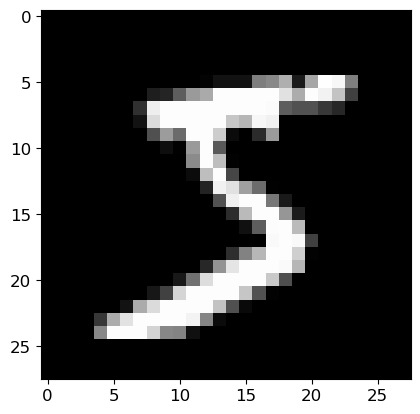

In [15]:
def show_image(img, label):
    print(f"Label: {label}")
    plt.imshow(img.squeeze(), cmap="gray")
    plt.show()

img, label = train_data[0]
show_image(img, label)


### Model Training
We train the model for 40 epochs:

In [17]:
# Train the model
epochs = 40
train_losses, train_accuracies = [], []
valid_losses, valid_accuracies = [], []

for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_dl, loss_func, opt)
    valid_loss, valid_acc = validate(model, test_dl, loss_func)
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_acc)
    print(f"Epoch {epoch+1}: Train Loss: {train_loss:.6f}, Train Acc: {train_acc:.6f}, Valid Loss: {valid_loss:.6f}, Valid Acc: {valid_acc:.6f}")


Epoch 1: Train Loss: 1.665795, Train Acc: 0.552450, Valid Loss: 0.760273, Valid Acc: 0.820100
Epoch 2: Train Loss: 0.549386, Train Acc: 0.855950, Valid Loss: 0.414149, Valid Acc: 0.887700
Epoch 3: Train Loss: 0.393258, Train Acc: 0.890350, Valid Loss: 0.347838, Valid Acc: 0.902100
Epoch 4: Train Loss: 0.344782, Train Acc: 0.902483, Valid Loss: 0.317415, Valid Acc: 0.910200
Epoch 5: Train Loss: 0.315688, Train Acc: 0.910667, Valid Loss: 0.294098, Valid Acc: 0.918900
Epoch 6: Train Loss: 0.292691, Train Acc: 0.917483, Valid Loss: 0.273882, Valid Acc: 0.922500
Epoch 7: Train Loss: 0.272767, Train Acc: 0.922967, Valid Loss: 0.257132, Valid Acc: 0.926500
Epoch 8: Train Loss: 0.256331, Train Acc: 0.927700, Valid Loss: 0.242074, Valid Acc: 0.934000
Epoch 9: Train Loss: 0.241836, Train Acc: 0.932350, Valid Loss: 0.230161, Valid Acc: 0.934600
Epoch 10: Train Loss: 0.228891, Train Acc: 0.935367, Valid Loss: 0.217504, Valid Acc: 0.937600
Epoch 11: Train Loss: 0.216896, Train Acc: 0.938550, Valid 

### Visualizing Model Predictions


True Label: 7
Predicted Label: 7


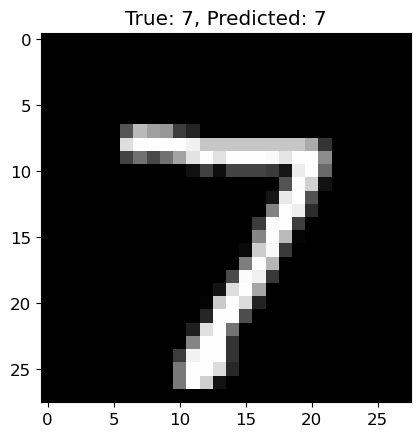

In [19]:
def show_prediction(model, img, label):
    model.eval()
    with torch.no_grad():
        pred = model(img.unsqueeze(0))
        predicted = pred.argmax(dim=1)
    
    print(f"True Label: {label}")
    print(f"Predicted Label: {predicted.item()}")
    plt.imshow(img.squeeze(), cmap="gray")
    plt.title(f"True: {label}, Predicted: {predicted.item()}")
    plt.show()

# Display a prediction
img, label = test_data[0]
show_prediction(model, img, label)


### Results Visualization
After training, we visualize the training and validation metrics:

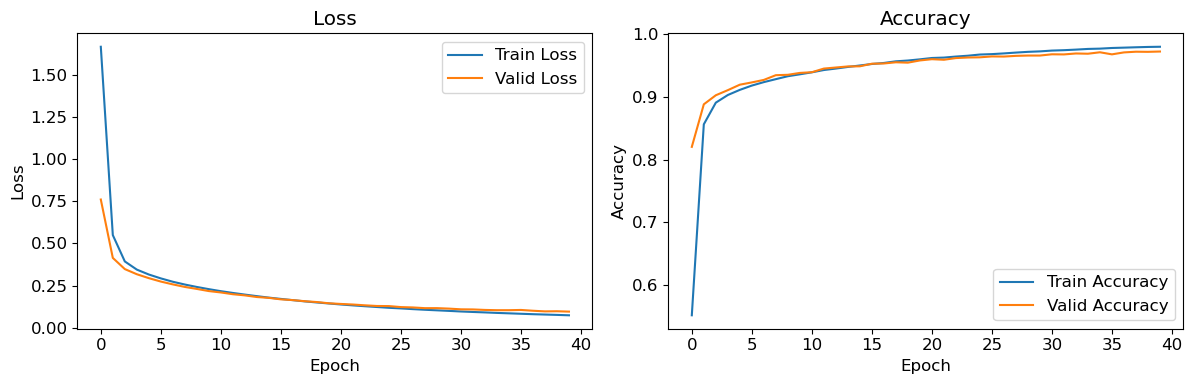

In [21]:
# Plot training and validation metrics
plt.figure(figsize=(12, 4))
plt.subplot(121)
plt.plot(train_losses, label='Train Loss')
plt.plot(valid_losses, label='Valid Loss')
plt.legend()
plt.title('Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.subplot(122)
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(valid_accuracies, label='Valid Accuracy')
plt.legend()
plt.title('Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.tight_layout()
plt.show()


## Results

The training results show significant improvement over the 40 epochs:

- Initial training loss: 1.665795, final training loss: 0.073921
- Initial validation loss: 0.760273, final validation loss: 0.095744
- Initial training accuracy: 55.24%, final training accuracy: 97.92%
- Initial validation accuracy: 82.01%, final validation accuracy: 97.16%

The model demonstrates strong learning progression throughout the training process:

- The training loss decreased dramatically in the first few epochs, from 1.67 to below 0.5, showing rapid initial learning
- Both training and validation accuracies improved steadily, reaching high performance levels
- The final validation accuracy of 97.16% indicates excellent generalization to unseen data
- The consistent improvement in both training and validation metrics suggests the model learned effectively without significant overfitting

The relatively small gap between final training (97.92%) and validation (97.16%) accuracies indicates good model generalization. The steady decrease in loss values and increase in accuracy across epochs demonstrates that the learning rate and model architecture were well-suited for this classification task.

